# Floor Collision Long-Run Simulation (GPU Check + CPU Fallback)

This notebook checks GPU availability first.
If GPU is not available, it runs a longer CPU fallback simulation so particles have enough time to collide with and settle on the floor.
Results are saved to a dedicated folder and rendered in screenshot-like style (no grids/axes).

In [1]:
from pathlib import Path
import sys
import time
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/workspaces/SnowSimulation')
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

OUT = ROOT / 'video_output' / 'floor_collision_long_results_faster'
OUT.mkdir(parents=True, exist_ok=True)

print('Workspace:', ROOT)
print('Output dir:', OUT)

Workspace: /workspaces/SnowSimulation
Output dir: /workspaces/SnowSimulation/video_output/floor_collision_long_results_faster


In [2]:
import warp as wp

gpu_report = {
    'nvidia_smi_found': shutil.which('nvidia-smi') is not None,
    'nvidia_smi_output': None,
    'nvidia_smi_error': None,
    'warp_version': None,
    'warp_cuda_available': None,
    'warp_cuda_alloc_test': None,
    'warp_cuda_error': None,
}

if gpu_report['nvidia_smi_found']:
    try:
        gpu_report['nvidia_smi_output'] = subprocess.check_output(['nvidia-smi', '-L'], text=True).strip()
    except Exception as e:
        gpu_report['nvidia_smi_error'] = str(e)
else:
    gpu_report['nvidia_smi_error'] = 'nvidia-smi command not found'

wp.init()
gpu_report['warp_version'] = wp.__version__
gpu_report['warp_cuda_available'] = bool(wp.is_cuda_available())

try:
    _tmp = wp.zeros(1, dtype=float, device='cuda')
    gpu_report['warp_cuda_alloc_test'] = 'ok'
except Exception as e:
    gpu_report['warp_cuda_alloc_test'] = 'failed'
    gpu_report['warp_cuda_error'] = str(e)

print('GPU Report:')
for k, v in gpu_report.items():
    print(f'- {k}: {v}')

use_gpu = gpu_report['warp_cuda_available'] and gpu_report['warp_cuda_alloc_test'] == 'ok'
print('\nUse GPU for this test:', use_gpu)
if not use_gpu:
    print('Reason: CUDA driver/device is not available to this notebook runtime, so Warp falls back to CPU.')

Warp 1.4.2 initialized:
   CUDA Toolkit 12.6, Driver 0.0 (insufficient CUDA driver version!)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /home/codespace/.cache/warp/1.4.2
Warp UserWarning: 
   Insufficient CUDA driver version.
   The minimum required CUDA driver version is 12.0, but the installed CUDA driver version is 0.0.
   Visit https://github.com/NVIDIA/warp/blob/main/README.md#installing for guidance.
GPU Report:
- nvidia_smi_found: False
- nvidia_smi_output: None
- nvidia_smi_error: nvidia-smi command not found
- warp_version: 1.4.2
- warp_cuda_available: False
- warp_cuda_alloc_test: failed
- warp_cuda_error: "cuda" device requested but CUDA is not supported by the hardware or driver

Use GPU for this test: False
Reason: CUDA driver/device is not available to this notebook runtime, so Warp falls back to CPU.


Warp CUDA error: Could not open libcuda.so.
Warp CUDA error: Function cuDriverGetVersion_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function cuda_driver_version, /builds/omniverse/warp/warp/native/warp.cu:1600)
Warp CUDA error: Function cuCtxGetCurrent_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function get_current_context, /builds/omniverse/warp/warp/native/warp.cu:235)
Warp CUDA error: Function cuCtxGetCurrent_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function get_current_context, /builds/omniverse/warp/warp/native/warp.cu:235)


In [3]:
from simulation.grid import Grid
from simulation.mpm_solver import MPMSolver
from simulation.snow_object import SnowObject, create_particle_system

# GPU path uses smaller particle diameter (more particles).
# CPU path uses fewer particles but longer duration to capture floor collision/settling.
if use_gpu:
    particle_diameter = 0.014
    grid_size = 48
    num_steps = 360
    capture_every = 20
else:
    particle_diameter = 0.028
    grid_size = 24
    num_steps = 320
    capture_every = 20

snow = SnowObject(particle_diameter=particle_diameter, target_density=320)

snowball = snow.create_snowball(
    radius=0.09,
    center=[0.45, 0.95, 0.75],
    # velocity=[0.0, -1.3, 0.0],
    velocity=[0.0, -13.0, 0.0],
)

cube1 = snow.create_snowcube(
    side_length=0.11,
    center=[1.0, 0.28, 0.75],
    # velocity=[0.0, -0.9, 0.0],
    velocity=[0.0, -10.0, 0.0],
)

cube2 = snow.create_snowcube(
    side_length=0.11,
    center=[1.0, 1.05, 0.75],
    # velocity=[0.0, -1.2, 0.0],
    velocity=[0.0, -13.0, 0.0],
)

particle_system = create_particle_system([snowball, cube1, cube2])
grid = Grid(size=grid_size, grid_space=0.015)
solver = MPMSolver(particle_system, grid)

print('Config:')
print('-', 'particle_diameter =', particle_diameter)
print('-', 'grid_size =', grid_size)
print('-', 'num_steps =', num_steps)
print('-', 'capture_every =', capture_every)
print('-', 'num_particles =', particle_system.num_particles)

Module simulation.grid f6df8f9 load on device 'cpu' took 1.47 ms  (cached)
Config:
- particle_diameter = 0.028
- grid_size = 24
- num_steps = 320
- capture_every = 20
- num_particles = 259


In [4]:
snapshots = []
steps = []

start_t = time.perf_counter()
solver.run_initial_step()
for step in range(num_steps + 1):
    if step % capture_every == 0:
        snapshots.append(solver.particle_system.positions.numpy().copy())
        steps.append(step)
    solver.run_time_step()
elapsed = time.perf_counter() - start_t

print('Captured snapshots:', len(snapshots))
print('Simulation elapsed seconds:', round(elapsed, 2))

Module simulation.particles 17dcb4d load on device 'cpu' took 0.41 ms  (cached)


Module simulation.collision_object 2cf0b4e load on device 'cpu' took 0.25 ms  (cached)
Captured snapshots: 17
Simulation elapsed seconds: 339.49


In [5]:
states_dir = OUT / 'states'
frames_dir = OUT / 'frames'
states_dir.mkdir(parents=True, exist_ok=True)
frames_dir.mkdir(parents=True, exist_ok=True)

for old_npz in states_dir.glob('*.npz'):
    old_npz.unlink()
for old_png in frames_dir.glob('*.png'):
    old_png.unlink()

saved_images = []
dark_blue = '#0B1F5E'

for idx, (step, pts) in enumerate(zip(steps, snapshots)):
    np.savez_compressed(states_dir / f'state_{idx:03d}_step_{step:03d}.npz', positions=pts, step=step)

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(dark_blue)
    ax.set_facecolor(dark_blue)

    # Two-layer points for glow-like screenshot style.
    ax.scatter(pts[:, 0], pts[:, 1], s=22, c='white', alpha=0.18, edgecolors='none')
    ax.scatter(pts[:, 0], pts[:, 1], s=7, c='white', alpha=0.96, edgecolors='none')

    ax.set_xlim(0.0, 1.5)
    ax.set_ylim(0.0, 1.5)
    ax.set_axis_off()
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    img_path = frames_dir / f'frame_{idx:03d}_step_{step:03d}.png'
    fig.savefig(img_path, dpi=150, bbox_inches='tight', pad_inches=0, facecolor=fig.get_facecolor())
    plt.close(fig)
    saved_images.append(img_path)

print('Saved state files:', len(list(states_dir.glob('*.npz'))))
print('Saved frame images:', len(saved_images))

Saved state files: 17
Saved frame images: 17


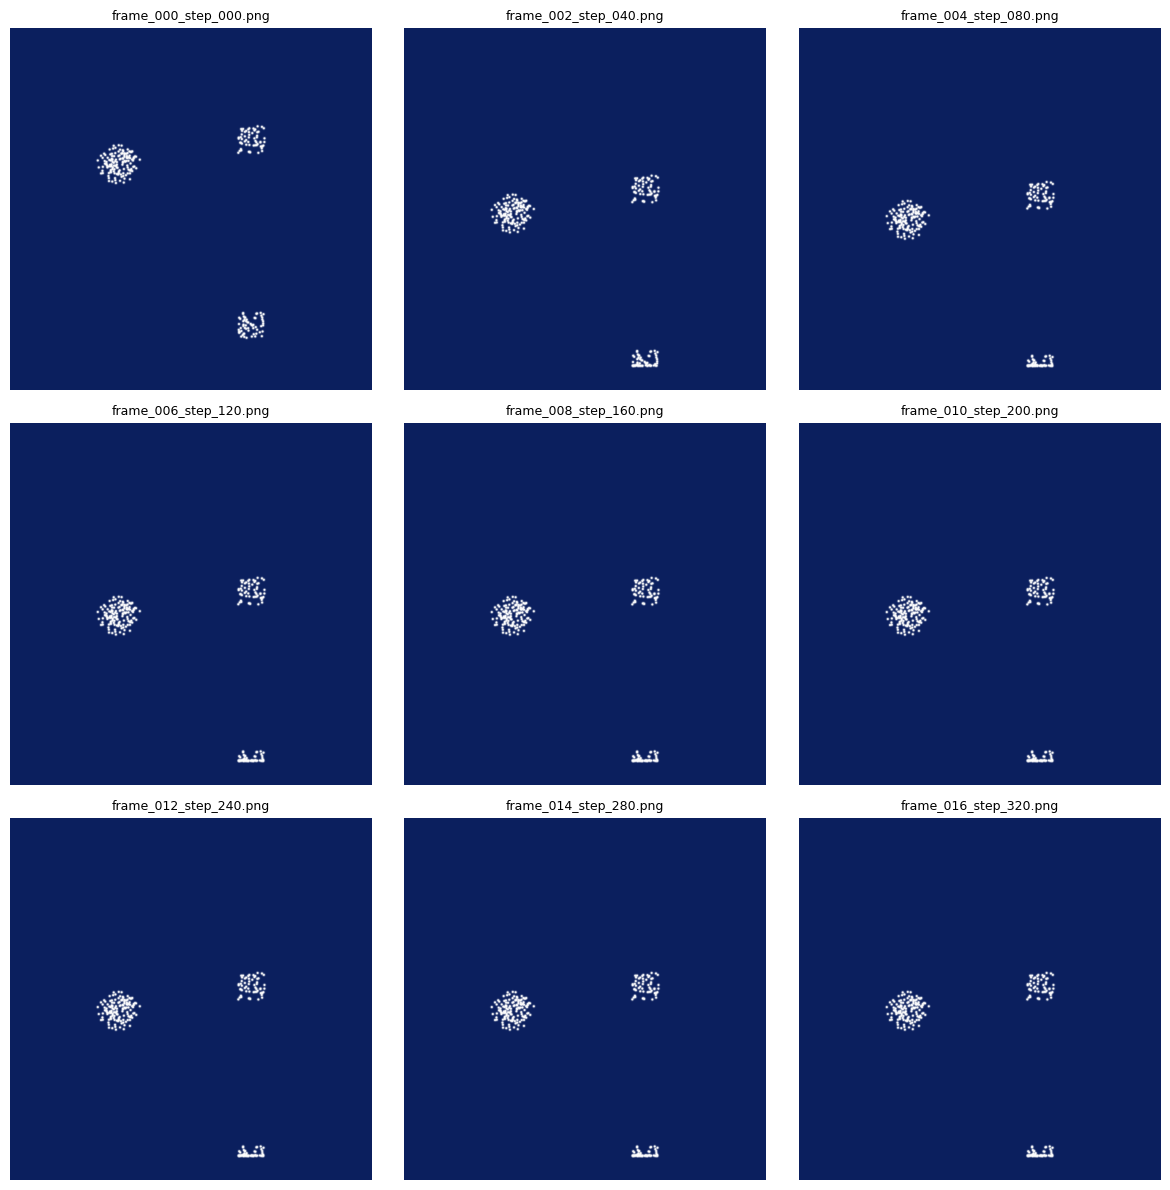

Result root: /workspaces/SnowSimulation/video_output/floor_collision_long_results_faster
Frames directory: /workspaces/SnowSimulation/video_output/floor_collision_long_results_faster/frames
States directory: /workspaces/SnowSimulation/video_output/floor_collision_long_results_faster/states
Sample output files:
- video_output/floor_collision_long_results_faster/frames/frame_000_step_000.png
- video_output/floor_collision_long_results_faster/frames/frame_001_step_020.png
- video_output/floor_collision_long_results_faster/frames/frame_002_step_040.png
- video_output/floor_collision_long_results_faster/frames/frame_003_step_060.png
- video_output/floor_collision_long_results_faster/frames/frame_004_step_080.png


In [6]:
preview_count = min(len(saved_images), 9)
indices = np.linspace(0, len(saved_images) - 1, preview_count, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = np.array(axes).reshape(-1)
for i in range(9):
    ax = axes[i]
    ax.set_facecolor(dark_blue)
    if i < preview_count:
        img = plt.imread(saved_images[indices[i]])
        ax.imshow(img)
        ax.set_title(saved_images[indices[i]].name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Result root:', OUT)
print('Frames directory:', frames_dir)
print('States directory:', states_dir)
print('Sample output files:')
for p in sorted(frames_dir.glob('*.png'))[:5]:
    print('-', p.relative_to(ROOT))